In [1]:
import seaborn as sb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
from tqdm import tqdm
sys.path.append('../')

import skimage
import mndino.mnds as mnds

In [12]:
datasets_colors = {'BBBC039':'#FFC0CB',
                   'mnfinder_validation':'#80ED99',
                   'mnDINO_data_01':'#192A56',
                   'mnDINO_data_02':'#00A3FF'}

plt.rcParams.update({'font.size':12})

# Performance

In [ ]:
df = pd.read_csv('/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures//mndino_figures/figure3/validation_performance.csv')
df.head()

,Precision,Recall,Model,Dataset
0,0.74,0.62,mnDINO,BBBC039
1,0.89,0.92,mnDINO,mnDINO_data_01
2,0.83,0.88,mnDINO,mnDINO_data_02
3,0.77,0.75,mnDINO,MNFinder Data
4,0.62,0.68,MNFinder,BBBC039


In [3]:
for group_keys, group_df in df.groupby(['Model']):
    print(f'Group: {group_keys}')
    print(group_df)
    print('------')

Group: ('Cellpose',)
    Precision  Recall     Model         Dataset
8        0.70    0.29  Cellpose         BBBC039
9        0.82    0.15  Cellpose  mnDINO_data_01
10       0.83    0.16  Cellpose  mnDINO_data_02
11       0.73    0.25  Cellpose   MNFinder Data
------
Group: ('MNFinder',)
   Precision  Recall     Model         Dataset
4       0.62    0.68  MNFinder         BBBC039
5       0.69    0.83  MNFinder  mnDINO_data_01
6       0.67    0.81  MNFinder  mnDINO_data_02
7       0.85    0.86  MNFinder   MNFinder Data
------
Group: ('microSAM',)
    Precision  Recall     Model         Dataset
12       0.45    0.10  microSAM         BBBC039
13       0.05    0.00  microSAM  mnDINO_data_01
14       0.39    0.02  microSAM  mnDINO_data_02
15       0.56    0.09  microSAM   MNFinder Data
------
Group: ('mnDINO',)
   Precision  Recall   Model         Dataset
0       0.74    0.62  mnDINO         BBBC039
1       0.89    0.92  mnDINO  mnDINO_data_01
2       0.83    0.88  mnDINO  mnDINO_data_02
3 

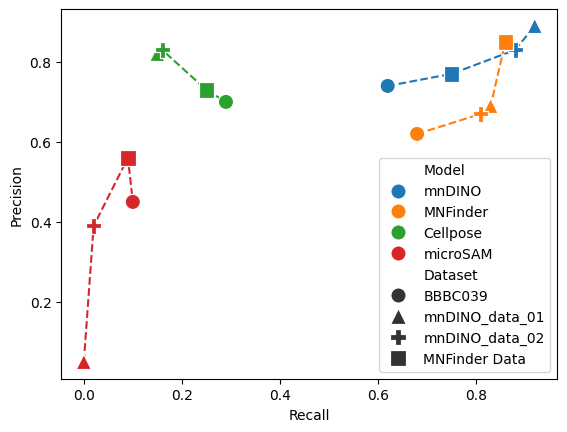

In [29]:
import seaborn as sb
import matplotlib.pyplot as plt

marker_map = {
    'BBBC039': 'o',           
    'mnDINO_data_02': 'P',   
    'MNFinder Data': 's',    
    'mnDINO_data_01': '^'    # '^' triangle
}

ax = sb.scatterplot(
    data=df,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Dataset',
    markers=marker_map,  # <-- This will now work
    s=120
)

palette = dict(zip(df['Model'].unique(), sb.color_palette()))

for model, group_data in df.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='--',
        zorder=0  # Put lines behind markers
    )
plt.show()

# Object Size

In [3]:
import sys
sys.path.append('../')
from mndino.evaluation import compare_two_labels, measures_at

In [4]:
# Hyperparameters
DIRECTORY = '/scr/yren/micronuclei-detection/dinomn/all_data_micronuclei_no_rescale/validation'
OUTPUT_DIR = '/model_output/output/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

In [10]:
filelist = os.listdir(DIRECTORY + OUTPUT_DIR)
files = [file for file in filelist if file.endswith('_probabilities.npy')]
print(len(files))

47


- Save IoUs

In [ ]:
for file in files:
    imid = file.split('.')[0]
    prob = np.load(DIRECTORY + OUTPUT_DIR + file)
    mn_pred = prob > THRESHOLD
    mn_gt = mnds.read_image(DIRECTORY, imid, 'phenotype_outlines.png', scale=SCALE_FACTOR)
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(pi, gti, True)
    
    matches = IoUs > 0.1
    ratio = []
    for i in range(0, matches.shape[0]):
        if (True in matches[i,:]):
            idx = np.where(matches[i,:]==True)[0][0]
            label_gt = i + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            ratio.append(area_gt/area_pred)
        else:
            ratio.append(0)
    
    print(imid, matches.shape, len(np.unique(pi)))
    mat = np.column_stack((matches, ratio))
    IoU_filename = f'/scr/yren/mndino_figures/figure3/IoUs/{imid}._IoUs.npy'
    np.save(IoU_filename, mat)

2022-05-26_RPE1-2198 (113, 84) 85
2022-10-14_U2OS-1 (63, 40) 41
2023-05-31_misc-4 (4, 7) 8
20X_c0-DAPI_A1_Tile-50 (163, 162) 163
C1-20X_c0_B3_Tile-24 (170, 163) 164
C1-20X_c0_phalloidin_C3_Tile-15 (75, 86) 87
C2-20X_c0-DAPI-GFP_A2_Tile-5 (83, 91) 92
C2-20X_c0-DAPI-GFP_B3_Tile-16 (100, 99) 100
IXMtest_B04_s4_w1F6AEFA0F-AF87-4B3B-A334-698647CFE043 (9, 9) 10
IXMtest_B12_s2_w19F7E0279-D087-4B5E-9899-61971C29CB78 (10, 7) 8
IXMtest_B19_s7_w1E43B84DB-39E2-4BFB-8CB4-554B32098C75 (7, 4) 5
IXMtest_B24_s9_w18C4FE0DD-12CA-4711-9722-3E3105D1E691 (5, 6) 7
IXMtest_C18_s1_w11C16FC59-2E29-496A-803A-89581FDF538A (12, 13) 14
IXMtest_D02_s8_w1AC6783DF-ED35-4818-8091-E6D02AF4BFBD (16, 20) 21
IXMtest_D07_s4_w16CF58D03-0B05-41FE-AE73-7298887DEBB1 (8, 10) 11
IXMtest_D19_s6_w1EB1F11AE-4FB6-481F-94D9-40246870F0CB (11, 8) 9
IXMtest_E06_s3_w1701573EB-CE9A-4D76-8668-0416996E1DCD (9, 5) 6
IXMtest_E12_s9_w1A811DEC0-ADD9-411A-B5D5-A654C70F253D (5, 4) 5
IXMtest_F08_s1_w144C3056F-C4DD-4D39-A40F-4F4576A6DBD8 (8, 7) 8
IX

In [5]:
path = '/scr/yren/mndino_figures/figure3/IoUs/'
filelist = os.listdir(path)
IoU_files = [file for file in filelist if file.endswith('._IoUs.npy')]
print(len(IoU_files))

47


## Plot

In [5]:
path = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/data_to_publish/annotated_mn_datasets/'
metadata = pd.read_csv(f'{path}metadata.csv')
metadata.head()

,filenames,datasets,magnification,micron,split,cell_line
0,C1-20X_c0_B3_Tile-5.tif,mnDINO_data_02,20,6.5,train,HeLa
1,C1-20X_c0_B3_Tile-24.tif,mnDINO_data_02,20,6.5,validation,HeLa
2,C1-20X_c0_B3_Tile-15.tif,mnDINO_data_02,20,6.5,test,HeLa
3,C1-20X_c0_phalloidin_C3_Tile-18.tif,mnDINO_data_02,20,6.5,train,RPE1
4,C1-20X_c0_phalloidin_C3_Tile-15.tif,mnDINO_data_02,20,6.5,validation,RPE1


In [ ]:
path = '/scr/yren/mndino_figures/figure3/IoUs/'
DIRECTORY = '/scr/yren/mndino_figures/mndino_validation_predictions/'
GT_DIRECTORY = '/scr/yren/annotated_mn_datasets/validation/mn_masks/'
SCALE_FACTOR = 1.0
THRESHOLD = 0.5

import pandas as pd

df = pd.DataFrame(columns = ['original_area', 'predicted_area', 'status'])

for i in tqdm(range(len(IoU_files))):
    IoU_path = path + IoU_files[i]
    matches = np.load(IoU_path)
    matches = matches[:,:-1] # remove last column which is ratio
    
    imid = IoU_files[i].split('.')[0]
    mn_pred = np.load(f'{DIRECTORY}{imid}._probabilities.npy') > THRESHOLD
    
    gt_path = os.path.join(GT_DIRECTORY, imid + '.png')
    mn_gt = skimage.io.imread(gt_path)
    mn_gt = mn_gt > 0
    
    pi = skimage.morphology.label(mn_pred)
    gti = skimage.morphology.label(mn_gt)
    
    original_area = []
    predicted_area = []
    status = [] # True/Flase
    # print(imid)
    conditions = (metadata.filenames == imid + '.tif') & (metadata.split == 'validation')
    dataset = metadata.loc[conditions, 'datasets'].item()
    
    for j in range(0, matches.shape[0]): # not detected should be 0 for predicted area
        if (True in matches[j,:]):
            idx = np.where(matches[j,:]==True)[0][0]
            label_gt = j + 1
            label_pred = idx + 1
            
            area_gt = np.sum(gti == label_gt)
            area_pred = np.sum(pi == label_pred)
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Detected') # detected
            
        else: # ground truth is not predicted by the model
            label_gt = j + 1
            area_gt = np.sum(gti == label_gt)
            area_pred = 0
            
            original_area.append(area_gt)
            predicted_area.append(area_pred)
            status.append('Missed') # not detected
            
    df_single_image = pd.DataFrame({'dataset':dataset, 'original_area':original_area, 'predicted_area':predicted_area, 'status':status})
    df = pd.concat([df, df_single_image], ignore_index=True)

100%|██████████| 47/47 [00:10<00:00,  4.51it/s]


- Save the dataframe

In [18]:
df.head()

,original_area,predicted_area,status,dataset
0,92,56,Detected,mnDINO_data_02
1,86,120,Detected,mnDINO_data_02
2,68,80,Detected,mnDINO_data_02
3,85,76,Detected,mnDINO_data_02
4,161,180,Detected,mnDINO_data_02


In [6]:
CSV_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/figure3/object_size.csv'

In [ ]:
# df.to_csv(CSV_PATH, index=False)

In [7]:
df = pd.read_csv(CSV_PATH)
df.head()

,original_area,predicted_area,status,dataset
0,92,56,Detected,mnDINO_data_02
1,86,120,Detected,mnDINO_data_02
2,68,80,Detected,mnDINO_data_02
3,85,76,Detected,mnDINO_data_02
4,161,180,Detected,mnDINO_data_02


In [10]:
df_detected = df[df['status'] == 'Detected'].copy()
df_detected['original_area'] = pd.to_numeric(df_detected['original_area'])
df_detected['predicted_area'] = pd.to_numeric(df_detected['predicted_area'])

/tmp/ipykernel_2020043/4023301148.py:56: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


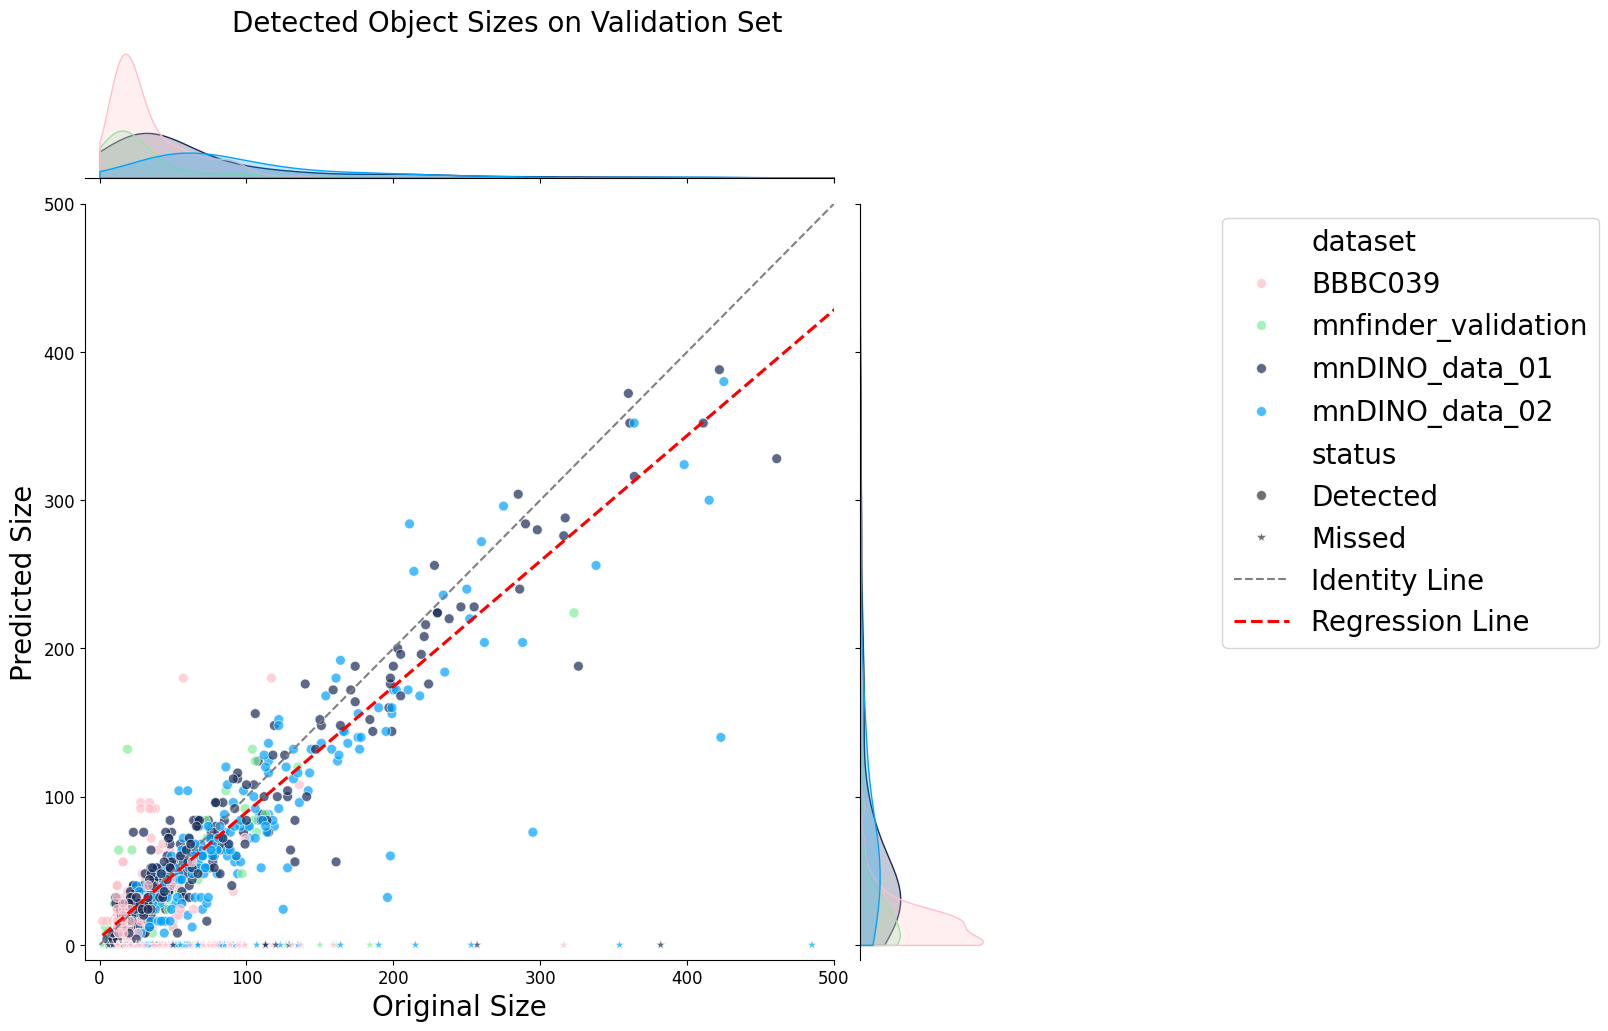

In [13]:
marker_map = {'Detected': 'o', 'Missed': '*'} 
labels = ['BBBC039', 'mnfinder_validation', 'mnDINO_data_01', 'mnDINO_data_02']

g = sb.JointGrid(
    data=df, 
    x='original_area', 
    y='predicted_area', 
    height=10,
)

g.plot_joint(
    sb.scatterplot,
    data=df,             
    hue='dataset', 
    hue_order=labels,   
    style='status',      
    markers=marker_map, 
    s=50,                
    alpha=0.7,
    palette=datasets_colors            
)

ax = g.ax_joint
# Add identity line
lims = [0, 500]
ax.plot(lims, lims, '--', color='gray', label='Identity Line')


sb.regplot(
    data=df_detected,
    x='original_area',
    y='predicted_area',
    scatter=False,    
    ax=ax,
    ci=None,
    color='red',
    line_kws={'linestyle':'--'},
    label='Regression Line',
)

g.plot_marginals(sb.kdeplot, data=df, fill=True, hue='dataset', clip=[0, 500], palette=datasets_colors) 
g.ax_joint.set_ylim([-10, 500])
g.ax_joint.set_xlim([-10, 500])

g.figure.suptitle('Detected Object Sizes on Validation Set', y=1.02, fontsize=20)
g.set_axis_labels(xlabel='Original Size', 
                  ylabel='Predicted Size', 
                  fontsize=20)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, 
          labels=labels, 
          fontsize=20, 
          loc='upper left',
          bbox_to_anchor = (1.5,1))
plt.tight_layout()
plt.show()

plt.show()